In [1]:
import os
import sys
sys.path.append("../..")

import dill as pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.distributions as td
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric as pyg
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool
from torch_geometric.datasets import TUDataset

from egg_models import egg_generic_losses
from egg_models.egg_generic import EggGeneric
from egg_models.egg_generic import EggGeneric
from functools import partial
from matplotlib.patches import ConnectionPatch
from scipy.stats import gaussian_kde, t
from sklearn.metrics import confusion_matrix

from utils import mutag_helper
from utils import visuals
import pygmtools as pygm
import networkx as nx

from egg_models.egg_generic_losses import activation_hook, dict_cos_dist, GEDasMatchLoss
from scipy.stats import stats

/opt/miniconda/envs/egg-env-38-test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/repo/results/MUTAG/../../utils/segmentation_functions.py:723: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if np.shape(RGB_img)[2] is not 3:


In [2]:
# Reproducibility
SEED = 123123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True 
np.random.seed(SEED)

#Meta-Data
device = torch.device(0)
node_types = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']
color_palette = np.array(['orange', 'magenta', 'green', 'blue', 'cyan', 'red', 'lime'])
color_palette_dropped = np.array(['orange', 'magenta', 'green', 'blue', 'red'])

# Data Prep

## Helper Functions

In [3]:
# Explainee Model
class GCN(torch.nn.Module):
    def __init__(self, node_features, hc1=64, hc2=32, hc3=16):
        super().__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(node_features, hc1)
        self.conv2 = GCNConv(hc1, hc2)
        self.conv3 = GCNConv(hc2, hc3)
        self.lin = nn.Linear(hc3, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # 1. Obtain node embeddings 
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        
        return x

In [4]:
def train_explainee(
    explainee: nn.Module,
    train_data: list, 
    test_data: list, 
    ):

    train_data_loader = pyg.loader.DataLoader(train_data, 
                                            batch_size=16, shuffle=True)
    test_data_loader = pyg.loader.DataLoader(test_data, 
                                            batch_size=16, shuffle=False)

    optimizer = torch.optim.Adam(explainee.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(201): 
        explainee.train()        
        for batch in train_data_loader: 
            out = explainee(batch)
            loss = criterion(out, batch.y)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

        explainee.eval()
        correct = 0
        for batch in train_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        train_accuracy = correct / len(train_data_loader.dataset)

        correct = 0
        for batch in test_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        test_accuracy = correct / len(test_data_loader.dataset)

        print(f"Epoch: {epoch} Train Accuracy: {train_accuracy} " + 
            f"Test Accuracy: {test_accuracy}")


    full_batch = pyg.data.Batch.from_data_list(test_data)
    explainee.eval()
    preds = explainee(full_batch).argmax(dim=1).numpy()
    targets = full_batch.y.numpy()

    conf_matrix = confusion_matrix(targets, preds)
    print(conf_matrix)

    return explainee

In [5]:
def extract_embeddings(
    explainee: nn.Module, 
    train_data: list, 
    ):

    activation_names = ["conv1", "conv2", "conv3"]
    train_avg_embedding_0 = {"conv1": [], "conv2": [], "conv3": []}
    train_avg_embedding_1 = {"conv1": [], "conv2": [], "conv3": []}
    pool_func = pyg.nn.global_mean_pool


    train_data_loader = pyg.loader.DataLoader(train_data)
    for batch in train_data_loader:
        explainee.eval()

        acts, remove_hooks = activation_hook(explainee, activation_names)
        out = explainee(batch)
        remove_hooks()

        if batch.y.item() == 0: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_0[name].append(
                    embed.detach().to('cpu')
                )

        if batch.y.item() == 1: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_1[name].append(
                    embed.detach().to('cpu')
                )
                
    for name in activation_names:
        train_avg_embedding_0[name] = torch.stack(
            train_avg_embedding_0[name]
        ).mean(dim=0)

        train_avg_embedding_1[name] = torch.stack(
            train_avg_embedding_1[name]
        ).mean(dim=0)

    return train_avg_embedding_0, train_avg_embedding_1

## Raw Data

In [6]:
# Raw data

# Download data. 
data_raw = TUDataset(root='data/TUDataset', name='MUTAG')

# Shuffle
data_raw = data_raw.shuffle()

# Split 
train_data = data_raw[:150]
test_data = data_raw[150:]

# Create data lists
train_data_list = []
train_data_list_0 = []
train_data_list_1 = []
test_data_list = []
test_data_list_0 = []
test_data_list_1 = []

for graph in train_data:
    train_data_list.append(graph)

    if graph.y.item() == 0: 
        train_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_1.append(graph)

for graph in test_data:
    test_data_list.append(graph)

    if graph.y.item() == 0: 
        test_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_1.append(graph)

In [7]:
explainee_raw = train_explainee(
    GCN(node_features=7), 
    train_data_list, test_data_list
)

Epoch: 0 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 1 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 2 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 3 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 4 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 5 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 6 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 7 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 8 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 9 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 10 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 11 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 12 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.

In [8]:
train_avg_embedding_0, train_avg_embedding_1 = extract_embeddings(
    explainee_raw, train_data_list
)
print(train_avg_embedding_0)
print(train_avg_embedding_1)

{'conv1': tensor([[-0.0222, -0.0055,  0.0484, -0.0590,  0.1123, -0.1477,  0.1512, -0.0603,
          0.3106,  0.0094, -0.1648,  0.0627,  0.0021, -0.0862, -0.1976, -0.0046,
         -0.0380,  0.0032, -0.0045, -0.1579, -0.0345,  0.1249,  0.0756, -0.1413,
          0.0171,  0.0245, -0.0479,  0.1650, -0.3137,  0.1725, -0.0321, -0.1159,
          0.0026, -0.1280,  0.0824, -0.0059, -0.0784,  0.0489, -0.0015,  0.1329,
         -0.0661, -0.0084,  0.0443, -0.0309, -0.0490, -0.1215, -0.1207,  0.0592,
         -0.0069,  0.0255,  0.0129,  0.0861, -0.0279, -0.1637,  0.0231,  0.0282,
         -0.0817, -0.0008, -0.0035,  0.0011, -0.0256,  0.0073,  0.1352, -0.0981]]), 'conv2': tensor([[-0.0678, -0.0443,  0.1740,  0.0016,  0.0449, -0.1202, -0.1617,  0.1414,
         -0.0964,  0.0024, -0.0934, -0.2123,  0.2427,  0.2472,  0.0756, -0.1039,
          0.1447, -0.0351, -0.0180,  0.1657, -0.0708, -0.1861, -0.2076,  0.0029,
         -0.1131, -0.2629,  0.1556,  0.2166, -0.0125, -0.0822,  0.1783,  0.1150]]), 'co

## Dropped

In [9]:
data_dropped = []

for graph in data_raw:
    node_types = graph.x.argmax(dim=-1)
    edge_types = graph.edge_attr.argmax(dim=-1)

    if torch.any(node_types == 4) or torch.any(node_types == 6) or torch.any(edge_types == 3): 
        print(graph) 
    else: 
        graph.x = torch.cat([graph.x[:, :4], graph.x[:, 5].unsqueeze(1)], dim=1)
        graph.edge_attr = graph.edge_attr[:, :3]
        data_dropped.append(graph)

data_dropped[1]

Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 28], x=[14, 7], edge_attr=[28, 4], y=[1])
Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 40], x=[18, 7], edge_attr=[40, 4], y=[1])


Data(edge_index=[2, 38], x=[17, 5], edge_attr=[38, 3], y=[1])

In [10]:
# Split 
train_data_dropped = data_dropped[:150]
test_data_dropped = data_dropped[150:]

# Create data lists
train_data_list_dropped = []
train_data_list_dropped_0 = []
train_data_list_dropped_1 = []
test_data_list_dropped = []
test_data_list_dropped_0 = []
test_data_list_dropped_1 = []

for graph in train_data_dropped:
    train_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        train_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_dropped_1.append(graph)

for graph in test_data_dropped:
    test_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        test_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_dropped_1.append(graph)

In [11]:
explainee_dropped = train_explainee(
    GCN(node_features=5), 
    train_data_list_dropped, 
    test_data_list_dropped
)  

Epoch: 0 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 1 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 2 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 3 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 4 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 5 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 6 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 7 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 8 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 9 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 10 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 11 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 12 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.

In [12]:
train_avg_embedding_0_dropped, train_avg_embedding_1_dropped = extract_embeddings(
    explainee_dropped, train_data_list_dropped
)
print(train_avg_embedding_0_dropped)
print(train_avg_embedding_1_dropped)

{'conv1': tensor([[-0.0255,  0.1250,  0.1851,  0.1884, -0.0072,  0.1248,  0.0226,  0.1809,
          0.1125, -0.0764, -0.0685, -0.0043, -0.0304, -0.0095,  0.0238,  0.0168,
          0.0425,  0.0455, -0.0464,  0.0159, -0.1923, -0.0194,  0.1060,  0.0042,
         -0.0187, -0.0100,  0.1574,  0.0600, -0.0049,  0.0149,  0.0264,  0.1324,
          0.0132,  0.0643,  0.1187, -0.0107, -0.0045,  0.0320, -0.0315,  0.0227,
         -0.0813, -0.0081,  0.0973, -0.1581, -0.0052, -0.2818,  0.1156,  0.0103,
          0.1555,  0.0642, -0.0093,  0.0160,  0.0623,  0.1068, -0.0299,  0.1723,
         -0.0091,  0.1418,  0.0137,  0.0653,  0.1781, -0.0169,  0.0503,  0.0912]]), 'conv2': tensor([[-0.1955,  0.1653,  0.1867, -0.1174,  0.2490,  0.1667,  0.2741,  0.2149,
         -0.0471,  0.0788, -0.2016, -0.2270,  0.1708, -0.2745, -0.2861, -0.3021,
         -0.2619, -0.1897, -0.0645, -0.2028, -0.1541,  0.1281,  0.1435, -0.0651,
          0.1663,  0.2404,  0.0007, -0.1311, -0.1665, -0.1529,  0.0491,  0.1774]]), 'co

# EGG

## Helper Functions

In [13]:
def t_confidence_interval(data):
    mean = np.mean(data)
    std_dev = np.std(data)

    print(f"Mean {mean} SD: {std_dev}")

    n = len(data)
    t_value = t.ppf(0.975, df=n-1) 
    margin_of_error = t_value * (std_dev / np.sqrt(n))
    lower_bound = np.round(mean - margin_of_error, 4)
    upper_bound = np.round(mean + margin_of_error, 4)

    print(f"({lower_bound}, {upper_bound})")

In [14]:
def pre_acc_interval(
    generator: nn.Module, 
    explainee: nn.Module, 
    target
    ):
    generator.eval()
    explainee.eval()

    pred_acc = []
    for i in range(1000):
        with torch.no_grad():
            gen_ex = mutag_helper.egg_to_ex(generator())
            pred = torch.softmax(explainee(gen_ex), dim=-1).mean(dim=0)
            pred_acc.append(pred[target].item())
    
    t_confidence_interval(pred_acc)

In [15]:
def GED_interval(
    generator: nn.Module, 
    GED_fn: nn.Module, 
    data_list: list, 
    batch_size=16, 
    ):
    generator.eval()
    loader = pyg.loader.DataLoader(data_list, 
                                   batch_size=batch_size, drop_last=True)
    running_GED = []
    for batch in loader:
        batch = batch.to(device)
        with torch.no_grad():
            generated = generator()
            gen_ex = mutag_helper.egg_to_ex(generated)
            gen_egg = mutag_helper.egg_to_egg(generated)
            obs_egg = mutag_helper.ex_to_egg(batch)

            egg_sizes = torch.tensor([
                graph.x.shape[0] + graph.edge_index.shape[1] 
                for graph in gen_ex.to_data_list()
            ]).to(device)

            loss = (
                GED_fn(*gen_egg, *obs_egg) / 
                egg_sizes
            ).mean()

            running_GED.append(min(loss.item(), 1.0))

    t_confidence_interval(running_GED)

In [16]:
def train_egg(
    dis_node_feats: int, 
    dis_edge_feats: int, 
    explainee: nn.Module, 
    target: int, 
    train_data_list_1, 
    train_data_list_0, 
    train_data_list_full, 
    pred_loss_embeds, 
    other_class_embeds,  
    max_node_size=20, 
    temp=0.15, 
    epochs=25, 
    loss_fn_weights=torch.tensor([1.0, 1.0, 1.0, 1.0]), 
    use_egg_size=False, 
    use_omega=True,  
    batch_size=16
    ):
    # Define target tensors. 
    if target == 1:
        target_tensor = torch.tensor([0.0, 1.0])
    else: 
        target_tensor = torch.tensor([1.0, 0.0])

    # Setup explainee. 
    explainee.eval()
    explainee.to(device)

    # Define generator to train. 
    generator = EggGeneric(
        max_node_size=max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=temp, 
        batch_size=batch_size, 
    )
    generator.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    # Compute random baseline.
    print("Baseline Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Baseline % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Baseline % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    # Train EGG model.
    train_loader = pyg.loader.DataLoader(train_data_list_full, 
                                         batch_size=batch_size, drop_last=True)
    pred_loss_fn = egg_generic_losses.PredLossBatched(
        target_tensor, explainee, avg_embed_targets=pred_loss_embeds
    )
    embed_dist_fn = egg_generic_losses.EmbDistGeneric(
        explainee, avg_embed_targets=other_class_embeds
    )
    edge_pen_fn = egg_generic_losses.EdgePenalty(edge_budget = 10)
    generator.train()
    optimizer = torch.optim.RMSprop(generator.parameters()) 
    for epoch in range(epochs):
        report_loss = np.array([0.0, 0.0, 0.0, 0.0])
        for obs_batch in train_loader: 
            optimizer.zero_grad()
            obs_batch = obs_batch.to(device)
            gen_graph = generator()

            # Data formatting. 
            gen_ex = mutag_helper.egg_to_ex(gen_graph) 
            gen_egg = mutag_helper.egg_to_egg(gen_graph)
            obs_egg = mutag_helper.ex_to_egg(obs_batch)

            loss_1, _, _ = pred_loss_fn(gen_ex)
            loss_1 = loss_1.mean()

            loss_embed = -1 * embed_dist_fn(gen_ex).mean()

            #loss_edge = torch.sum(generator.AdjacencyMatrix.probs, dim=0).mean()
            loss_edge = edge_pen_fn(generator.AdjacencyMatrix.probs)

            loss_2 = GED_fn(*gen_egg, *obs_egg)
            if use_egg_size:
                egg_size = torch.tensor([
                    graph.x.shape[0] + graph.edge_index.shape[1] 
                    for graph in gen_ex.to_data_list()
                ]).to(loss_2.device)
            else: 
                egg_size = 1.0
            
            if use_omega:
                with torch.no_grad():
                    explainee_pred = F.softmax(explainee(obs_batch), dim=-1)
                    omega = (explainee_pred @ 
                        target_tensor.to(explainee_pred.device) - 0.5
                    )
            else:
                omega = 1
            loss_3 = (omega * loss_2 / egg_size).mean()

            report_loss += [loss_1.item(), loss_embed.item(), 
                            loss_edge.item(), loss_3.item()]
            report_loss
            loss = (
                loss_fn_weights.to(loss_1.device) @ 
                torch.stack((loss_1, loss_embed, loss_edge, loss_3)) 
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)

            optimizer.step() 

        report_loss = [x / len(train_loader) for x in report_loss]
        print(f"Epoch: {epoch} Losses:{report_loss}")

    print("Trained Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Trained % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Trained % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    return generator 

In [17]:
# Visualize Connected Graph
def vis_con_graph(
    generator: nn.Module, 
    explainee: nn.Module, 
    dis_node_feats: int, 
    dis_edge_feats: int, 
    target: int, 
    obs_ex1, 
    obs_ex2, 
    color_palette=color_palette
    ):

    generator_batch_1 = EggGeneric(
        max_node_size=generator.max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=generator.temp, 
        batch_size=1, 
    )
    generator_batch_1.load_state_dict(generator.state_dict())
    generator_batch_1.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=generator.max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    gen = generator_batch_1()
    gen_ex = mutag_helper.egg_to_ex(gen)
    gen_egg = mutag_helper.egg_to_egg(gen)
    colors0 = color_palette[torch.argmax(gen_ex.x, dim=-1).cpu().numpy()]
    gen_nx = pyg.utils.to_networkx(gen_ex)

    obs_ex1 = obs_ex1.to(device)
    obs_egg1 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex1]))
    colors1 = color_palette[torch.argmax(obs_ex1.x, dim=-1).cpu().numpy()]
    obs_nx = pyg.utils.to_networkx(obs_ex1)

    obs_ex2 = obs_ex2.to(device)
    obs_egg2 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex2]))
    colors2 = color_palette[torch.argmax(obs_ex2.x, dim=-1).cpu().numpy()]
    obs_nx2 = pyg.utils.to_networkx(obs_ex2)

    with torch.no_grad():
        aff_mat = GED_fn.get_aff_mat(*gen_egg, *obs_egg1)
        dis_match_mat = GED_fn.get_dis_match_mat(aff_mat)

    with torch.no_grad():
        aff_mat2 = GED_fn.get_aff_mat(*gen_egg, *obs_egg2)
        dis_match_mat2 = GED_fn.get_dis_match_mat(aff_mat2)

    egg_size = torch.tensor([
        graph.x.shape[0] + graph.edge_index.shape[1] 
        for graph in gen_ex.to_data_list()
    ]).to(device)

    GED_score1 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat, aff_mat) / 
        egg_size
    ).item()
    GED_score1 = min(GED_score1, 1.0) # cap at 100% edit.

    GED_score2 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat2, aff_mat2) / 
        egg_size
    ).item()
    GED_score2 = min(GED_score2, 1.0)


    pos_1 = nx.spring_layout(obs_nx)
    # pos_2 = nx.spring_layout(gen_nx)
    pos_2 = {}
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        pos_2[i] = pos_1[j]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    nx.draw(obs_nx, node_color = colors1, pos = pos_1, ax=axes[0])

    nx.draw(gen_nx, node_color = colors0, pos=pos_2, ax=axes[1])

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_2[i], xyB=pos_1[j], 
                            coordsA="data", coordsB="data",
                            axesA=axes[0], axesB=axes[1], color="green")

        fig.add_artist(con)

    pos_3 = nx.spring_layout(obs_nx2)
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        pos_3[j] = pos_2[i]

    nx.draw(obs_nx2, node_color = colors2, pos = pos_3, ax=axes[2])

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_3[j], xyB=pos_2[i], 
                            coordsA="data", coordsB="data",
                            axesA=axes[2], axesB=axes[1], color="blue")

        fig.add_artist(con)

    explainee.eval()
    with torch.no_grad():
        pred_gen = torch.softmax(explainee(gen_ex), -1)[:, target].item()
        pred_obs1 = torch.softmax(explainee(obs_ex1), -1)[:, target].item()
        pred_obs2 = torch.softmax(explainee(obs_ex2), -1)[:, target].item()

    axes[0].set_title(f"Class Probability: {pred_obs1:0.2f} GED: {GED_score1:0.2f}")
    axes[1].set_title(f"Class Probability: {pred_gen:0.2f}")
    axes[2].set_title(f"GED: {GED_score2:0.2f} Class Probability: {pred_obs2:0.2f}")

# Results

## Re-implementationn of GNNInterpreter

In [18]:
gen_gnnInt_1 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.0311334263854078 SD: 0.02934076128074222
(0.0293, 0.033)
Baseline % GED to 1


/opt/miniconda/envs/egg-env-38-test/lib/python3.10/site-packages/pygmtools/pytorch_backend.py:1546: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing_keys, unexpected_ke

Mean 0.09147401366915021 SD: 0.0020981335949567886
(0.0895, 0.0934)
Baseline % GED to 0
Mean 0.07551203792293866 SD: 0.004647012322700845
(0.0706, 0.0804)
Epoch: 0 Losses:[2.5283397869630293, -0.41524987667798996, 10799.083629261364, 2.6481529745188626]
Epoch: 1 Losses:[1.6883992877873508, -0.9594191421161998, 2366.460682262074, 2.704731599851088]
Epoch: 2 Losses:[1.123935043811798, -1.3384279771284624, 874.2637384588069, 2.8217740709131416]
Epoch: 3 Losses:[0.970312319018624, -1.458978295326233, 314.247783314098, 2.7975657148794695]
Epoch: 4 Losses:[0.8105760541829196, -1.5710763497786089, 127.60961151123047, 2.8262965895912866]
Epoch: 5 Losses:[0.7071315158497203, -1.657118407162753, 53.530208587646484, 2.9476696361194956]
Epoch: 6 Losses:[0.5945408019152555, -1.7480502020228992, 22.53540680625222, 2.911480112509294]
Epoch: 7 Losses:[0.6313297233798287, -1.7117706428874622, 10.222267541018399, 2.9338856393640693]
Epoch: 8 Losses:[0.579931687224995, -1.7486915588378906, 5.515949335965

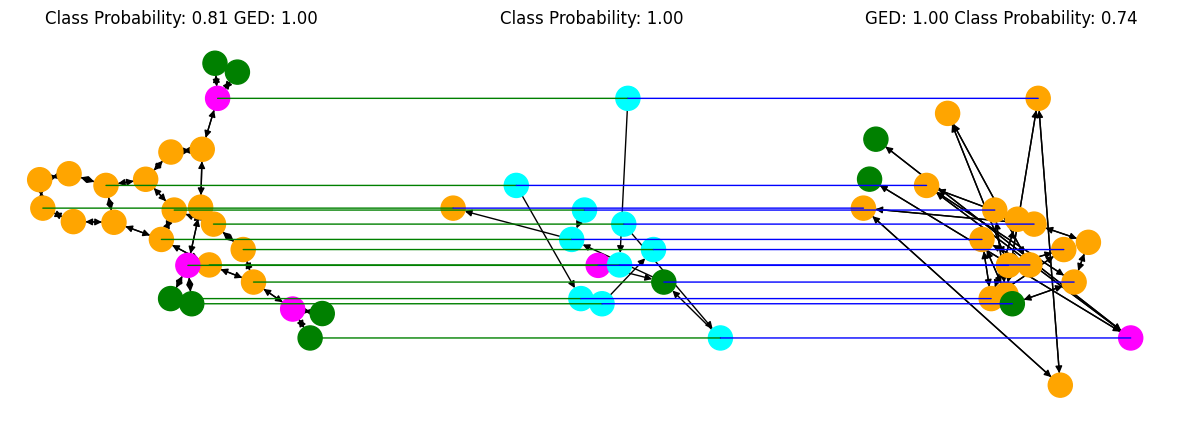

In [19]:
vis_con_graph(
    gen_gnnInt_1, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [20]:
gen_gnnInt_0 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 


KeyboardInterrupt: 

In [ ]:
vis_con_graph(
    gen_gnnInt_0,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[2].clone(), 
    obs_ex2=test_data_list_0[3].clone(), 
    target=0
)

In [ ]:
gen_gnnInt_1_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_1_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[1].clone(), 
    obs_ex2=test_data_list_dropped_1[5].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [ ]:
gen_gnnInt_0_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_0_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Multi-Layer Embedding Similarity

In [ ]:
gen_gnnInt_1_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_1_ml, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [ ]:
gen_gnnInt_0_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_0_ml,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [ ]:
gen_gnnInt_1_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_1_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [ ]:
gen_gnnInt_0_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_0_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Opposing Class Embeddings

In [ ]:
gen_gnnInt_1_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_1_oc, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [ ]:
gen_gnnInt_0_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_0_oc,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [ ]:
gen_gnnInt_1_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_1_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [ ]:
gen_gnnInt_0_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_0_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Only GED

In [ ]:
gen_gnnInt_1_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-4, 1.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_1_GED, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[3].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [ ]:
gen_gnnInt_0_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_0_GED,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [ ]:
gen_gnnInt_1_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_1_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [ ]:
gen_gnnInt_0_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_0_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Full Loss

In [ ]:
gen_gnnInt_1_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_1_full, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [ ]:
gen_gnnInt_0_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1e6]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_0_full,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [ ]:
gen_gnnInt_1_dropped_full = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
    epochs=25
)

In [ ]:
vis_con_graph(
    gen_gnnInt_1_dropped_full, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [ ]:
gen_gnnInt_0_dropped_full = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
)

In [ ]:
vis_con_graph(
    gen_gnnInt_0_dropped_full, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Parameter Distribution

In [ ]:
data_0 = train_data_list_0 + test_data_list_0
data_1 = train_data_list_1 + test_data_list_1

batch_0 = pyg.data.Batch.from_data_list(data_0)
batch_1 = pyg.data.Batch.from_data_list(data_1)

In [ ]:
edge_probs_0 = gen_gnnInt_0_full.AdjacencyMatrix.probs
edge_probs_0 = edge_probs_0.detach().cpu().numpy()

edge_probs_1 = gen_gnnInt_1_full.AdjacencyMatrix.probs
edge_probs_1 = edge_probs_1.detach().cpu().numpy()

# edge_probs_untrained = generator_untrained.AdjacencyMatrix.probs
# edge_probs_untrained = edge_probs_untrained.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(edge_probs_0, cmap='viridis', interpolation='nearest')
im1 = axes[1].imshow(edge_probs_1, cmap='viridis', interpolation='nearest')
#im2 = axes[2].imshow(edge_probs_untrained, cmap='viridis', interpolation='nearest')

# Add a common color bar
cbar = fig.colorbar(im1, ax=axes.ravel().tolist())
cbar.set_label('Edge Probability')

# Set titles
axes[0].set_title('Nonmutagenic')
axes[1].set_title('Mutagenic')
# axes[2].set_title('Untrained')

# Set common x and y labels
fig.text(0.45, 0.04, 'Nodes', ha='center')
fig.text(0.04, 0.5, 'Nodes', va='center', rotation='vertical')

plt.show()

In [ ]:
edge_probs_0 = gen_gnnInt_0_oc.AdjacencyMatrix.probs
edge_probs_0 = edge_probs_0.detach().cpu().numpy()

edge_probs_1 = gen_gnnInt_1_oc.AdjacencyMatrix.probs
edge_probs_1 = edge_probs_1.detach().cpu().numpy()

# edge_probs_untrained = generator_untrained.AdjacencyMatrix.probs
# edge_probs_untrained = edge_probs_untrained.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(edge_probs_0, cmap='viridis', interpolation='nearest')
im1 = axes[1].imshow(edge_probs_1, cmap='viridis', interpolation='nearest')
#im2 = axes[2].imshow(edge_probs_untrained, cmap='viridis', interpolation='nearest')

# Add a common color bar
cbar = fig.colorbar(im1, ax=axes.ravel().tolist())
cbar.set_label('Edge Probability')

# Set titles
axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
# axes[2].set_title('Untrained')

# Set common x and y labels
fig.text(0.45, 0.04, 'Nodes', ha='center')
fig.text(0.04, 0.5, 'Nodes', va='center', rotation='vertical')

plt.show()

In [ ]:
cell_type_probs_0 = torch.softmax(gen_gnnInt_0_full.DisNodeFeats[0].probs, dim=0)
cell_type_probs_0 = cell_type_probs_0.detach().cpu().numpy()

cell_type_probs_1 = torch.softmax(gen_gnnInt_1_full.DisNodeFeats[0].probs, dim=0)
cell_type_probs_1 = cell_type_probs_1.detach().cpu().numpy()

# cell_type_probs_untrained = torch.softmax(
#     generator_untrained.DisNodeFeats[0].probs, dim=0)
# cell_type_probs_untrained = cell_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, cell_type_probs_0, color=color_palette)
axes[1].bar(plot_indices, cell_type_probs_1, color=color_palette)
#axes[2].bar(plot_indices, cell_type_probs_untrained, color=color_palette)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

In [ ]:
cell_type_probs_0 = torch.softmax(gen_gnnInt_0_oc.DisNodeFeats[0].probs, dim=0)
cell_type_probs_0 = cell_type_probs_0.detach().cpu().numpy()

cell_type_probs_1 = torch.softmax(gen_gnnInt_1_oc.DisNodeFeats[0].probs, dim=0)
cell_type_probs_1 = cell_type_probs_1.detach().cpu().numpy()

# cell_type_probs_untrained = torch.softmax(
#     generator_untrained.DisNodeFeats[0].probs, dim=0)
# cell_type_probs_untrained = cell_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, cell_type_probs_0, color=color_palette)
axes[1].bar(plot_indices, cell_type_probs_1, color=color_palette)
#axes[2].bar(plot_indices, cell_type_probs_untrained, color=color_palette)

axes[0].set_title('Nonmutagenic')
axes[1].set_title('Mutagenic')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

In [ ]:
emp_dist_node_0 = batch_0.x.argmax(dim=-1).numpy()
emp_dist_node_1 = batch_1.x.argmax(dim=-1).numpy()

# Empirical node type probabilities
unique_classes_0, counts_0 = np.unique(emp_dist_node_0, return_counts=True)
percentages_0 = (counts_0 / len(emp_dist_node_0))
percentages_0 = np.insert(percentages_0, 4, 0.0) # missing I

unique_classes_1, counts_1 = np.unique(emp_dist_node_1, return_counts=True)
percentages_1 = (counts_1 / len(emp_dist_node_1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']

axes[0].bar(plot_indices, percentages_0, color=color_palette)
axes[1].bar(plot_indices, percentages_1, color=color_palette)

axes[0].set_title('Nonmutagenic')
axes[1].set_title('Mutagenic')

plt.tight_layout()
plt.show()

In [ ]:
edge_type_probs_0 = torch.softmax(gen_gnnInt_0_full.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_0 = edge_type_probs_0.detach().cpu().numpy()

edge_type_probs_1 = torch.softmax(gen_gnnInt_1_full.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_1 = edge_type_probs_1.detach().cpu().numpy()

# edge_type_probs_untrained = torch.softmax(
#     generator_untrained.DisEdgeFeats[0].probs, dim=0)
# edge_type_probs_untrained = edge_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, edge_type_probs_0)
axes[1].bar(plot_indices, edge_type_probs_1)
#axes[2].bar(plot_indices, edge_type_probs_untrained)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

In [ ]:
edge_type_probs_0 = torch.softmax(gen_gnnInt_0_oc.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_0 = edge_type_probs_0.detach().cpu().numpy()

edge_type_probs_1 = torch.softmax(gen_gnnInt_1_oc.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_1 = edge_type_probs_1.detach().cpu().numpy()

# edge_type_probs_untrained = torch.softmax(
#     generator_untrained.DisEdgeFeats[0].probs, dim=0)
# edge_type_probs_untrained = edge_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, edge_type_probs_0)
axes[1].bar(plot_indices, edge_type_probs_1)
#axes[2].bar(plot_indices, edge_type_probs_untrained)

axes[0].set_title('Nonmutagenic')
axes[1].set_title('Mutagenic')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

In [ ]:
# Empirical edge type probabilities
emp_dist_edge_0 = batch_0.edge_attr.argmax(dim=-1).numpy()
emp_dist_edge_1 = batch_1.edge_attr.argmax(dim=-1).numpy()

unique_classes_0, counts_0 = np.unique(emp_dist_edge_0, return_counts=True)
percentages_0 = (counts_0 / len(emp_dist_edge_0))
percentages_0 = np.insert(percentages_0, 3, 0.0) # no triples. 

unique_classes_1, counts_1 = np.unique(emp_dist_edge_1, return_counts=True)
percentages_1 = (counts_1 / len(emp_dist_edge_1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(edge_types, percentages_0)
axes[1].bar(edge_types, percentages_1)

axes[0].set_title('Nonmutagenic')
axes[1].set_title('Mutagenic')

plt.tight_layout()
plt.show()

### Clean-UP

In [21]:
import gc

# Get all objects in the current context
for obj in gc.get_objects():
    if torch.is_tensor(obj) and obj.is_cuda:
        del obj

# Clear the cache
torch.cuda.empty_cache()

# Optionally synchronize (wait for GPU computations to finish)
torch.cuda.synchronize()

/opt/miniconda/envs/egg-env-38-test/lib/python3.10/site-packages/torch/__init__.py:836: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)
